In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
l5_df = pd.read_csv("Landsat5_Metadata_Export.csv")

l7_df = pd.read_csv("Landsat7_Metadata_Export.csv")

In [3]:
l5_df['date'] = pd.to_datetime(l5_df['date'])
l7_df['date'] = pd.to_datetime(l7_df['date'])


In [4]:
l5_df['tile_id'] = l5_df['WRS_PATH'].astype(int).astype(str) + '-' + l5_df['WRS_ROW'].astype(int).astype(str)

l7_df['tile_id'] = l7_df['WRS_PATH'].astype(int).astype(str) + '-' + l7_df['WRS_ROW'].astype(int).astype(str)


In [5]:
(l5_df['CLOUD_COVER'] == -1).sum()

np.int64(0)

In [6]:
l5_df['tile_id'].drop_duplicates().size

45

In [7]:
l5_df["CLOUDLESS"] = 100 - l5_df['CLOUD_COVER']

# add month and year col
l5_df["month"] = l5_df['date'].dt.month
l5_df["year"] = l5_df['date'].dt.year

l7_df["CLOUDLESS"] = 100 - l7_df['CLOUD_COVER']

# add month and year col
l7_df["month"] = l7_df['date'].dt.month
l7_df["year"] = l7_df['date'].dt.year

In [8]:
import seaborn as sns
import matplotlib.dates as mdates

In [9]:
# 1. Set the high-level theme
sns.set_theme(style="whitegrid", font="sans-serif", rc={'figure.figsize':(25,10)})

# 2. Configure specific aesthetics
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1.5})

# 3. Choose a color palette (Set2 is great for distinct tile IDs)
palette = sns.color_palette("Set2")

<Axes: xlabel='CLOUD_COVER', ylabel='Percent'>

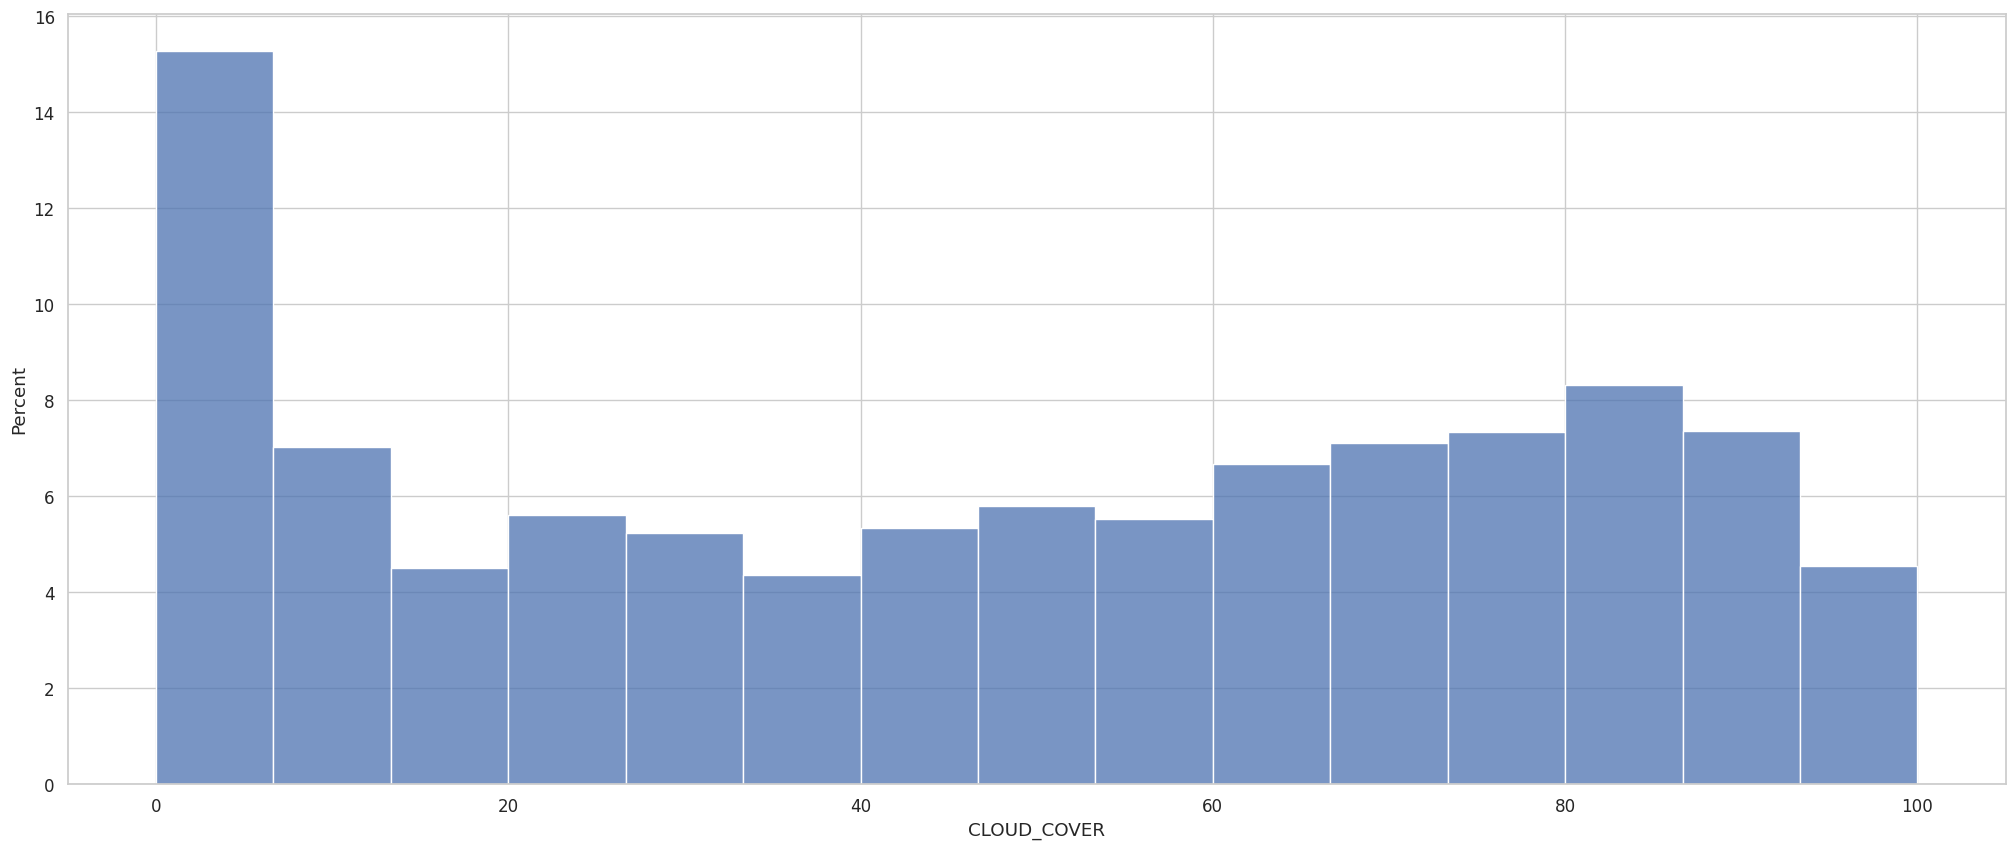

In [10]:
sns.histplot(data=l5_df, x='CLOUD_COVER', stat='percent')

In [11]:
custom_palette = sns.blend_palette(["#d3d3d3", "#95a5a6", "#f1c40f"], as_cmap=True)

Text(0.5, 1.0, 'Cloudless (> 80 % clear sky) observations per scene')

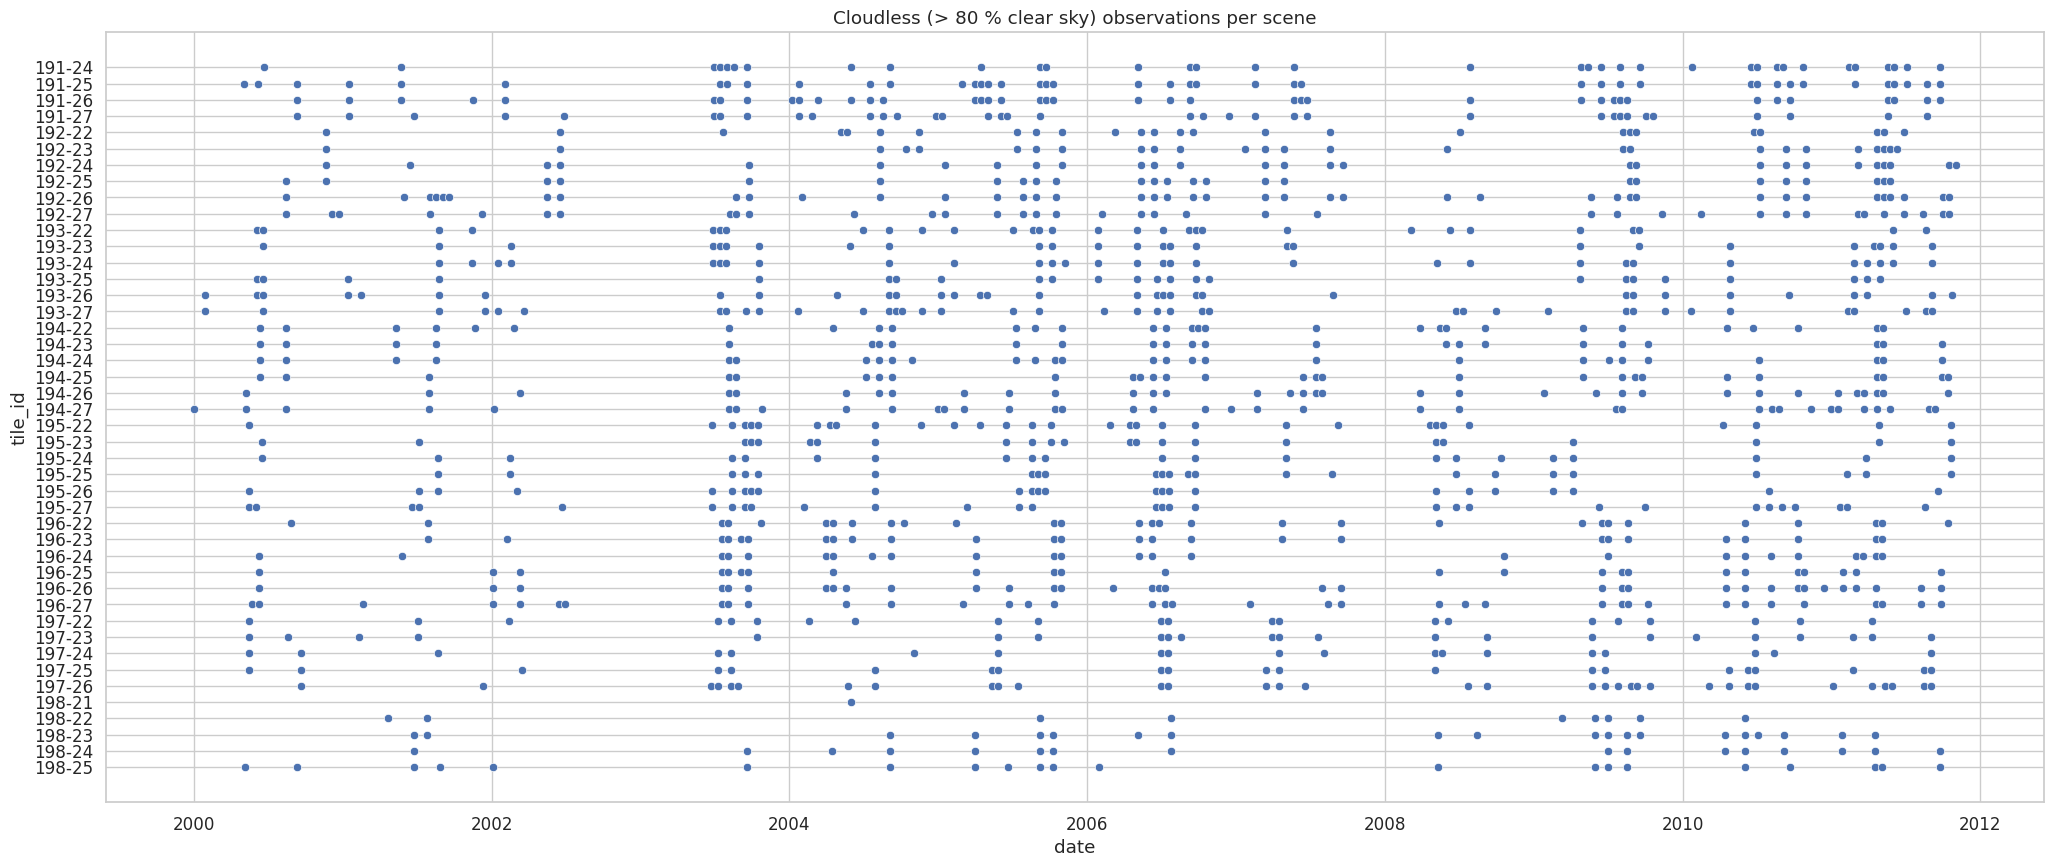

In [12]:
ax = sns.scatterplot(l5_df[l5_df['CLOUD_COVER'] < 20], x='date', y='tile_id')
ax.set_title("Cloudless (> 80 % clear sky) observations per scene")

Text(0.5, 1.0, 'Cloudless (> 95 % clear sky) observations per scene')

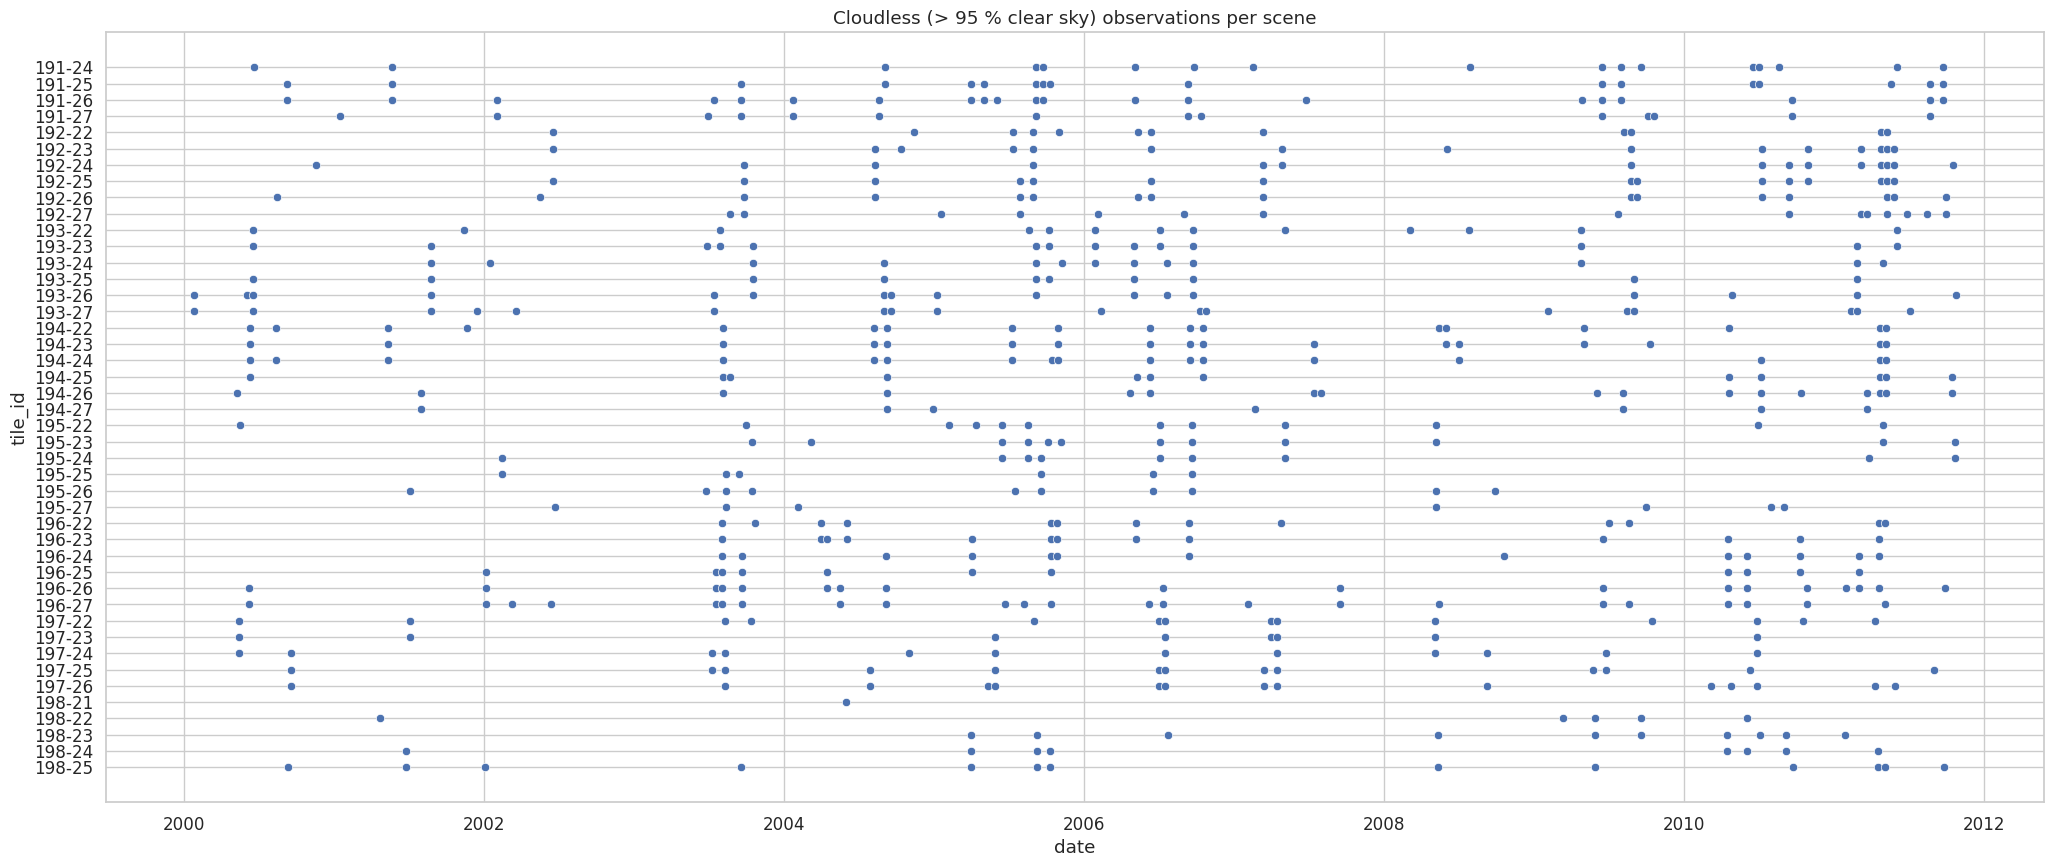

In [13]:
ax = sns.scatterplot(l5_df[l5_df['CLOUD_COVER'] < 5], x='date', y='tile_id')
ax.set_title("Cloudless (> 95 % clear sky) observations per scene")

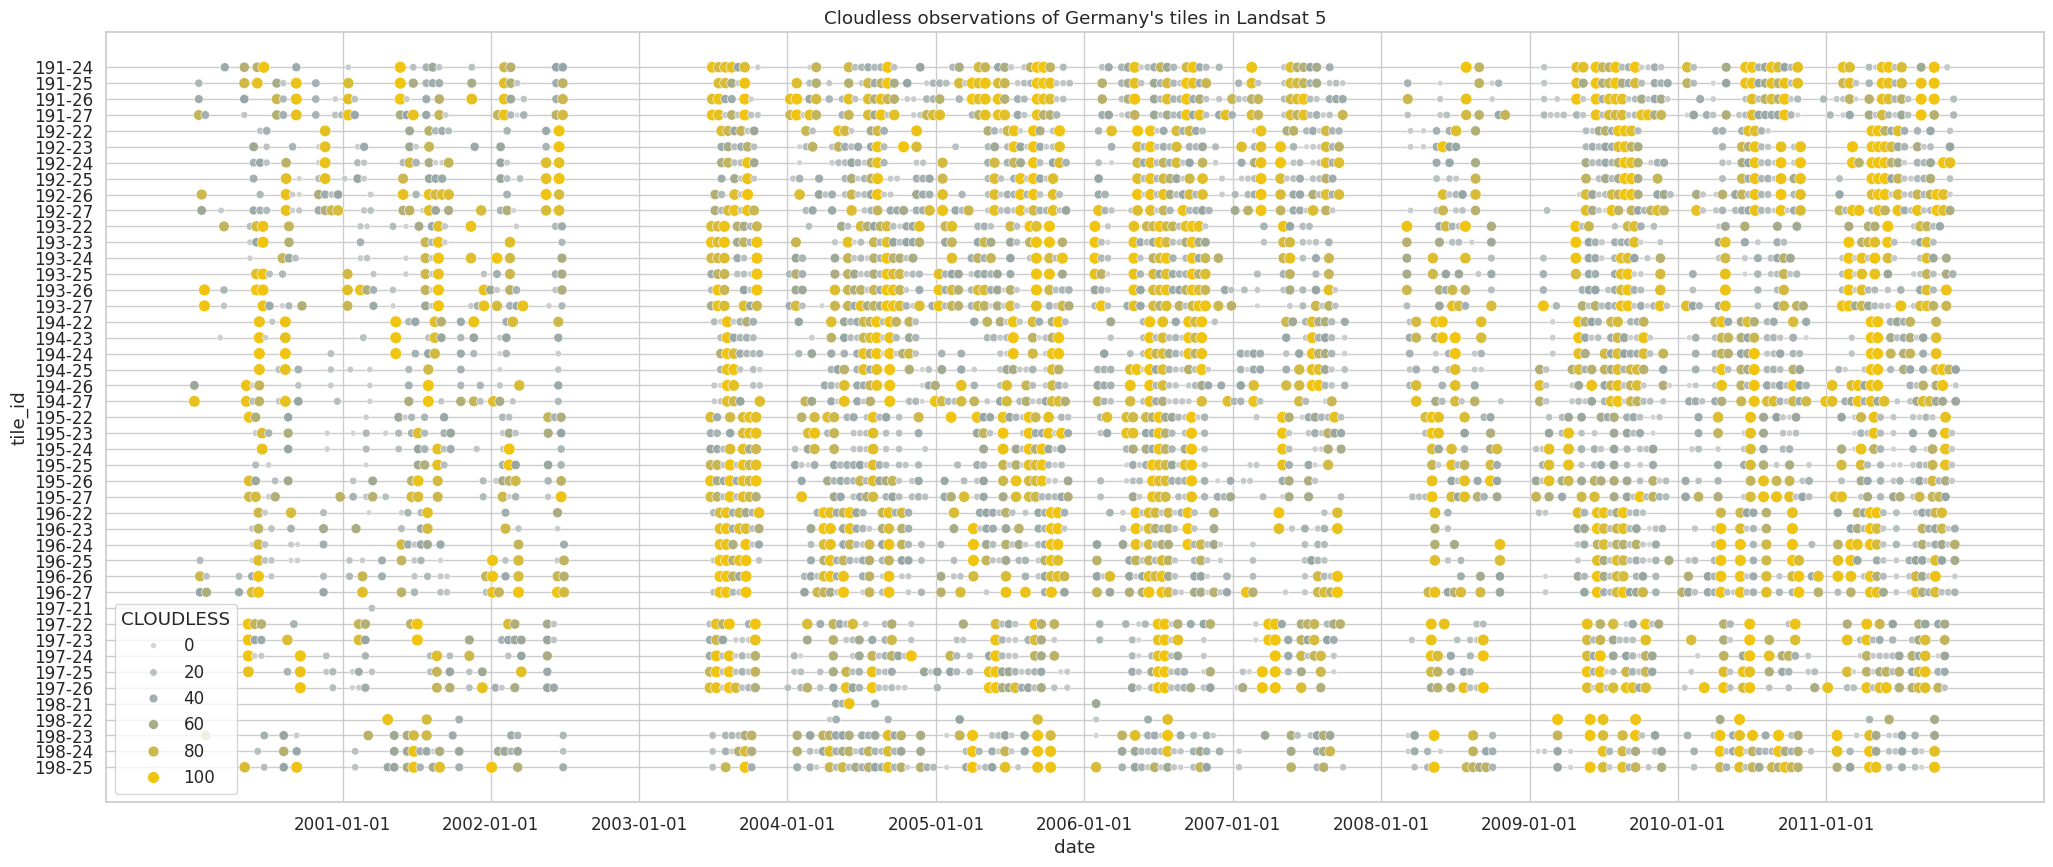

In [14]:
ax = sns.scatterplot(l5_df, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", palette=custom_palette)

years = pd.date_range(l5_df['date'].min(), l5_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 5")
plt.show()

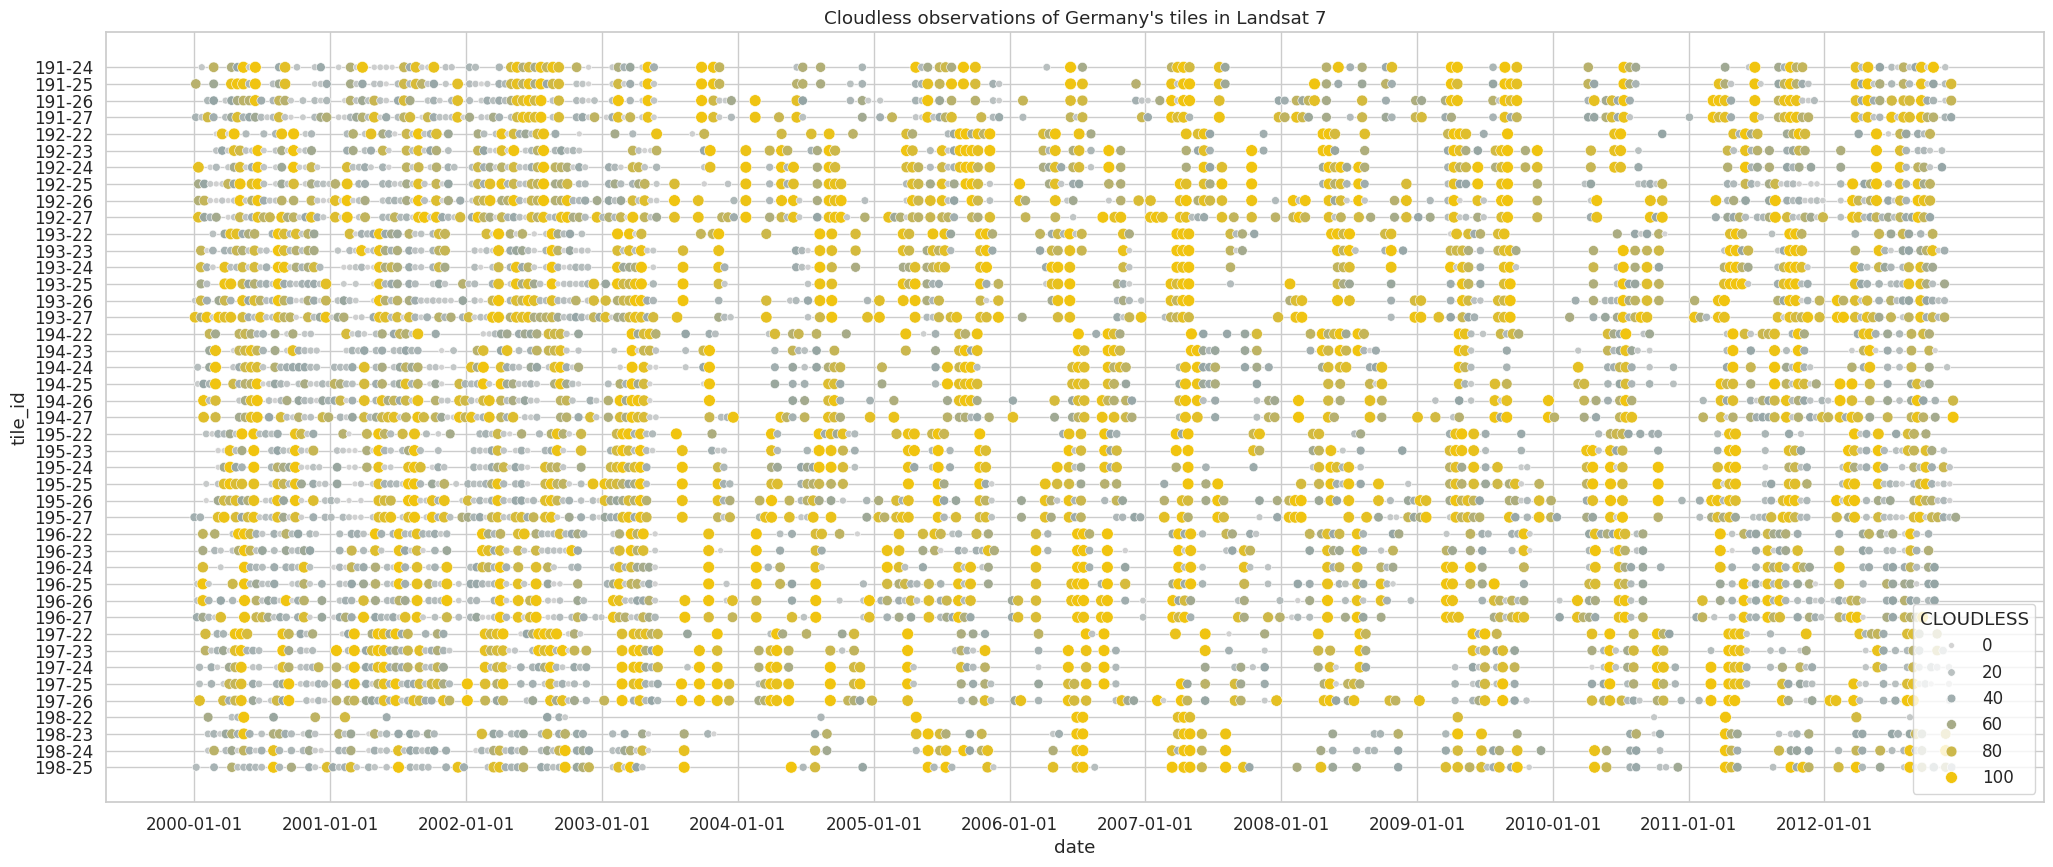

In [15]:
ax = sns.scatterplot(l7_df, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", palette=custom_palette)

years = pd.date_range(l7_df['date'].min(), l7_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 7")
plt.show()

In [16]:
l5_df['source'] = 'landsat5'
l7_df['source'] = 'landsat7'

landsat_df = pd.concat([l5_df, l7_df])
landsat_df

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,tile_id,CLOUDLESS,month,year,source
0,LT05_191024_20000317,2000-03-17,191.0,24.0,55.0,9.0,191-24,45.0,3,2000,landsat5
1,LT05_191024_20000504,2000-05-04,191.0,24.0,33.0,9.0,191-24,67.0,5,2000,landsat5
2,LT05_191024_20000605,2000-06-05,191.0,24.0,31.0,9.0,191-24,69.0,6,2000,landsat5
3,LT05_191024_20000621,2000-06-21,191.0,24.0,1.0,9.0,191-24,99.0,6,2000,landsat5
4,LT05_191024_20000909,2000-09-09,191.0,24.0,55.0,9.0,191-24,45.0,9,2000,landsat5
...,...,...,...,...,...,...,...,...,...,...,...
5366,LE07_198025_20120903,2012-09-03,198.0,25.0,88.0,9.0,198-25,12.0,9,2012,landsat7
5367,LE07_198025_20120919,2012-09-19,198.0,25.0,36.0,9.0,198-25,64.0,9,2012,landsat7
5368,LE07_198025_20121021,2012-10-21,198.0,25.0,50.0,9.0,198-25,50.0,10,2012,landsat7
5369,LE07_198025_20121122,2012-11-22,198.0,25.0,36.0,9.0,198-25,64.0,11,2012,landsat7


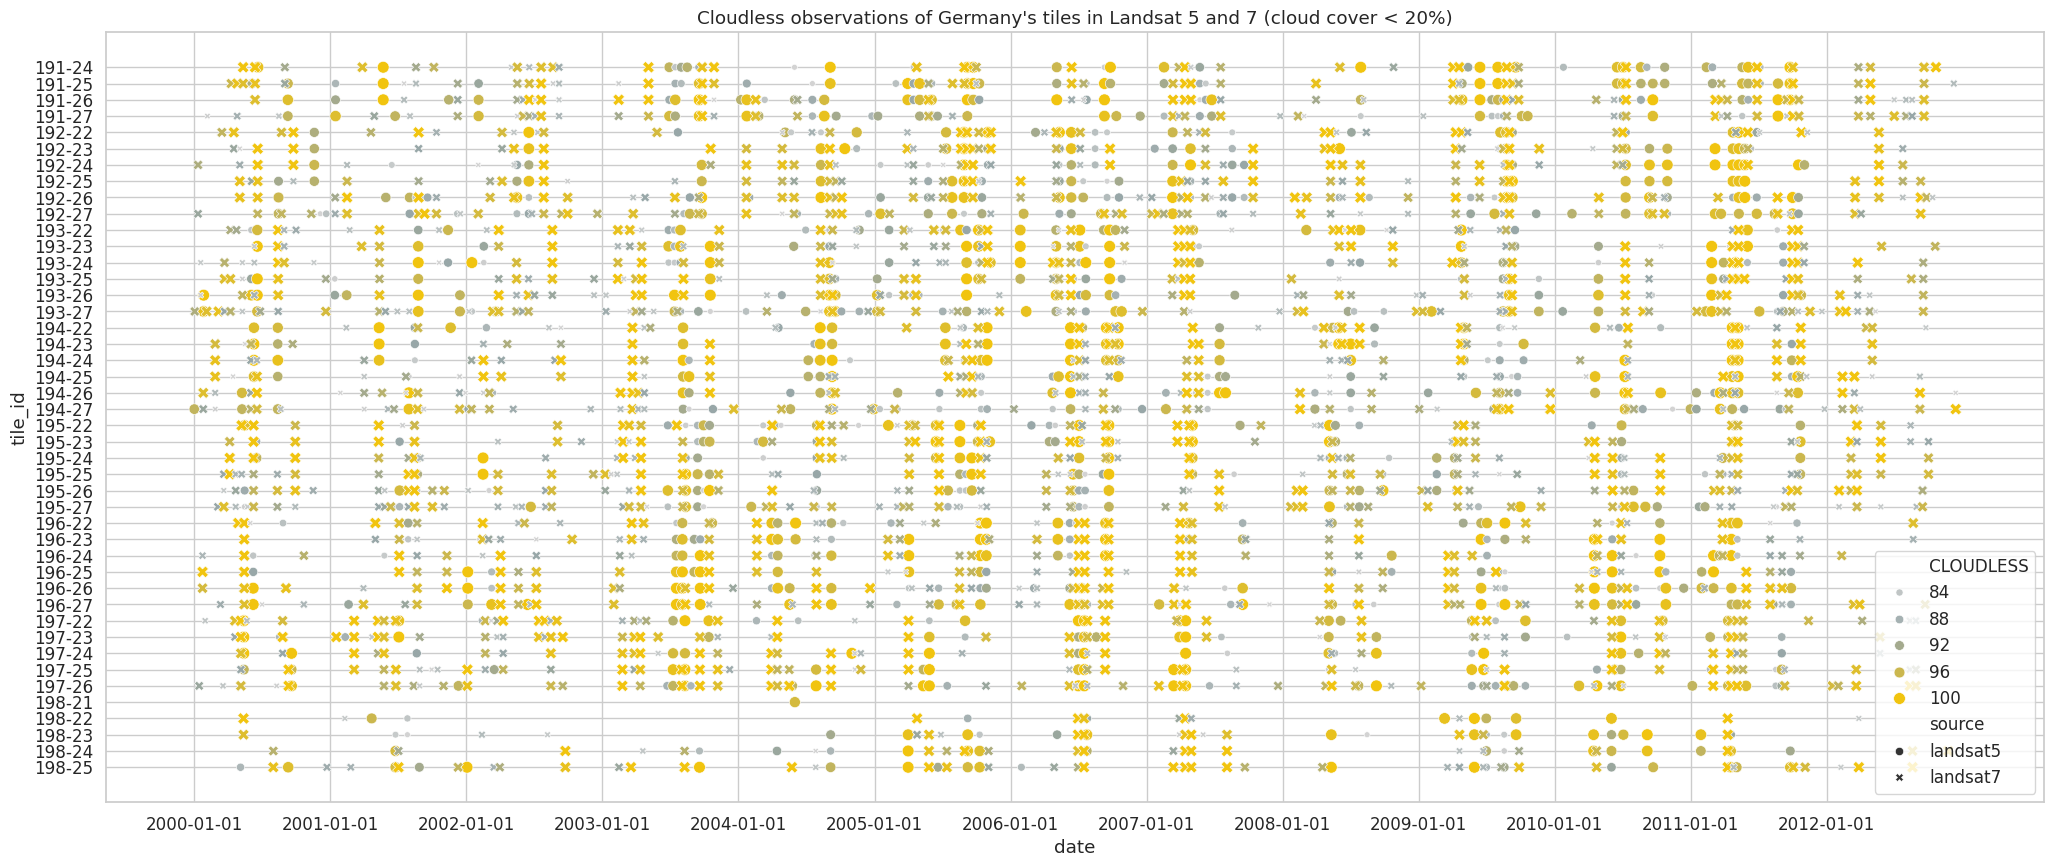

In [16]:
ax = sns.scatterplot(landsat_df[landsat_df["CLOUD_COVER"] < 20], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(landsat_df['date'].min(), landsat_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 5 and 7 (cloud cover < 20%)")
plt.show()

In [20]:
import geopandas as gpd

relevant_gdf = gpd.read_file("relevant_tiles_99perc.gpkg")

In [25]:
def filter_df_relevant(df, df_relevant):

    idx = pd.MultiIndex.from_frame(df_relevant[['WRS_PATH','WRS_ROW']].astype('float'))

    df_filtered = df[
        pd.MultiIndex.from_arrays([df.WRS_PATH, df.WRS_ROW]).isin(idx)
    ]

    return df_filtered


In [26]:
landsat_df_relevant = filter_df_relevant(landsat_df, relevant_gdf)
landsat_df_relevant

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,tile_id,CLOUDLESS,month,year,source
591,LT05_192023_20000527,2000-05-27,192.0,23.0,43.0,9.0,192-23,57.0,5,2000,landsat5
592,LT05_192023_20000628,2000-06-28,192.0,23.0,82.0,9.0,192-23,18.0,6,2000,landsat5
593,LT05_192023_20000831,2000-08-31,192.0,23.0,67.0,9.0,192-23,33.0,8,2000,landsat5
594,LT05_192023_20001103,2000-11-03,192.0,23.0,97.0,9.0,192-23,3.0,11,2000,landsat5
595,LT05_192023_20001119,2000-11-19,192.0,23.0,6.0,9.0,192-23,94.0,11,2000,landsat5
...,...,...,...,...,...,...,...,...,...,...,...
4897,LE07_197025_20120827,2012-08-27,197.0,25.0,8.0,9.0,197-25,92.0,8,2012,landsat7
4898,LE07_197025_20120912,2012-09-12,197.0,25.0,87.0,9.0,197-25,13.0,9,2012,landsat7
4899,LE07_197025_20120928,2012-09-28,197.0,25.0,68.0,9.0,197-25,32.0,9,2012,landsat7
4900,LE07_197025_20121014,2012-10-14,197.0,25.0,98.0,9.0,197-25,2.0,10,2012,landsat7


In [27]:
threshold = 20
early_months = [2, 3, 4]
late_months = [10, 11]

df_detect = landsat_df_relevant[
    (landsat_df_relevant['CLOUD_COVER'] < threshold)
    & (landsat_df_relevant['month'].isin(early_months + late_months))
]

mask = (
    df_detect.groupby(['year', 'tile_id'])['month']
    .agg(lambda m: any(m.isin(early_months)) and any(m.isin(late_months)))
)

valid_groups = mask[mask].index  # MultiIndex of (year, tile_id)

# 3) Filter to only valid groups
df_full = landsat_df_relevant.set_index(['year', 'tile_id']).loc[valid_groups].reset_index()

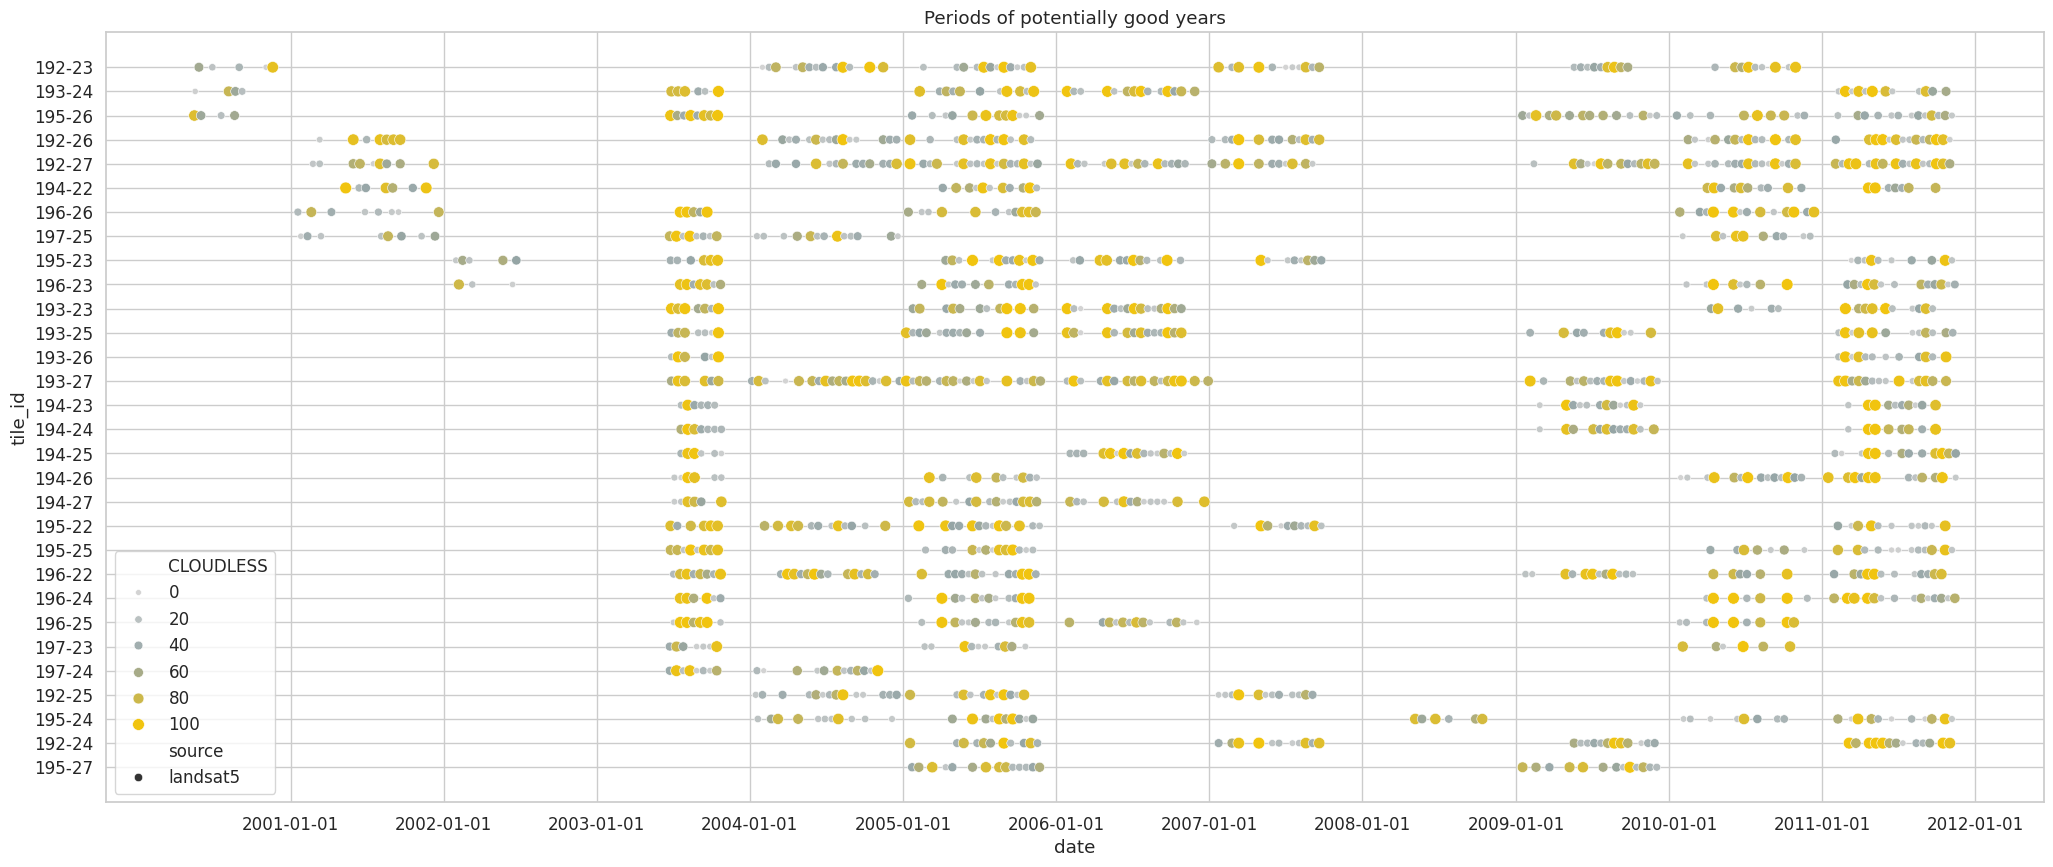

In [29]:
ax = sns.scatterplot(df_full[df_full["source"] == "landsat5"], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(df_full['date'].min(), df_full['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Periods of potentially good years")
plt.show()